<a href="https://colab.research.google.com/github/Angappan95/langchain-practice/blob/main/05_LanggraphMemory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install langchain langgraph python-dotenv notebook langchain-google-genai

In [2]:
from google.colab import userdata
GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')

In [3]:
from langchain.chat_models import init_chat_model

try:
  llm = init_chat_model("google_genai:gemini-2.5-flash", google_api_key=GOOGLE_API_KEY)
except Exception as e:
  print(f"Unable to load Gemini model {e}")

In [4]:
from typing import TypedDict
from langgraph.graph.message import Annotated, add_messages

class State(TypedDict):
  messages: Annotated[list, add_messages]

In [5]:
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition

@tool
def get_stock_price(stock: str):
    """
    Return the current stock price for the given ticker
    """
    stock_prices = {
        "HDFC": "45.00",
        "SBIN": "37.85",
        "ONGC": "84.25",
        "INFY": "100",
        "TCS": "102",
        "BEL": "98"
    }
    return stock_prices.get(stock, "NA")

In [6]:
tools = [get_stock_price]

In [7]:
def chatbot(state: State):
    return {"messages": [llm.invoke(state['messages'],tools=tools)]}

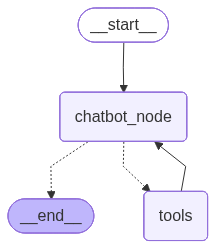

In [8]:
from langgraph.graph import StateGraph
from langgraph.graph.state import START, END

builder = StateGraph(State)
builder.add_node("chatbot_node", chatbot)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "chatbot_node")
builder.add_conditional_edges("chatbot_node", tools_condition)
builder.add_edge("tools", "chatbot_node")
builder.add_edge("chatbot_node", END)

graph = builder.compile()
graph

##Memory

In [9]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

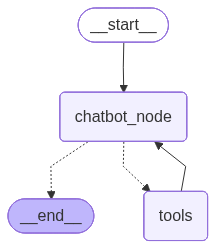

In [10]:
from langgraph.graph import StateGraph
from langgraph.graph.state import START, END

builder = StateGraph(State)
builder.add_node("chatbot_node", chatbot)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "chatbot_node")
builder.add_conditional_edges("chatbot_node", tools_condition)
builder.add_edge("tools", "chatbot_node")
builder.add_edge("chatbot_node", END)

graph = builder.compile(checkpointer=memory)
graph

In [11]:
config = {'configurable': {'thread_id': '1'}}
message = "Calculate the total price of 10 qtys of TCS stock and 15 qtys of INFY stock"
state = graph.invoke({'messages': [message]}, config=config)
state

{'messages': [HumanMessage(content='Calculate the total price of 10 qtys of TCS stock and 15 qtys of INFY stock', additional_kwargs={}, response_metadata={}, id='37029f91-2e0c-4baa-aa10-567ef2efb287'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'get_stock_price', 'arguments': '{"stock": "TCS"}'}, '__gemini_function_call_thought_signatures__': {'221f96c5-66b0-4202-9e46-73946ec97296': 'CrIHAQw51sexJmcqo09DdYedo7XZe4fgKwsEyOIaPBvxA3AJyhXF3AhNG61N97ocetuq5YJxY+TDPpMO76pq/k6xgwAQij14NGkjWGg+i5BspMRxZdw/FfU5VmUpCZeZNB3KevRt2UQAzpxcuZuZdVRkLGl5NJM8o2LzIXvMNdB0XHGuCYC1LEgO56iknIz7Nn0me1XvDYsQYCAOeOM0tnyOulFH7vp0MDi3VbiuNjuRkBeO4uDg0moLOHt2FcVozFDIV0vbkcL2HYPrLggz135DNwn7I17oIUZF2kW1RSNL4fAbPAtu/w3rGyHPRE08ssWZTgUuFOBf3mkZR+fC/bsPrcCrshQ/LLTz9jy+F1EDO4qoaLxExB8zS/fa/1/KmaJW8HhdSumwS6uOqmW22GJ74ShNSWH9LVs34vR+gkplOx7FtxkAgr5veYorCiNGcWoCjKBjjiWV9Kn8Y9AIXJ3TFN7wyfpxw/ScCARV3/fjqfccORiYtRjAvKWhUgV1yUc9+yKv+8SNrCmBNDYyDkrOpJLTuNrHdC6OWtG9FTZscptb7QQG57mymVS1xYs9kPYFUf2FK0h

In [12]:
print(state['messages'][-1].content)

[{'type': 'text', 'text': 'The total price of 10 qtys of TCS stock and 15 qtys of INFY stock is 2520.', 'extras': {'signature': 'CvsCAQw51scmKkqN+pU6dc/Q9iFiqPc86c/FnQsn0HErEOmuQbHNM0nd3XJWklC48K+1iyHTnJE1SZFT9WQEYsYZlW34M8n+m44oQRmWnKacWpUlWqjXbQEdxZ/uW4MDoA0W+5ueS56hLgBJfCt6/YkxXj6kt/jVy2TVTAKvmT9azYFfOI555Wqc5vZNIkbt16MZdf4bq+d6DuFHtqY44l27xy6liM2gbt6A8OzsnCuai1WzqusfbeYQ4lv3VhKeWe0HjlJUR/W/VkG9Bnv4PgYaS/q9dyiR7LrVywvmtE6wkif+F9WOHLAj2Sd+CG4phSSP7hM8Dil5OcofFJDxISKJ7upw7cdQNdhH1awbYuxXmKd5dWCUTuL0UzyVPYGLsMxzH4jY39FQsfnJyUC7Y2xf00Of0SnJamszBbLW7b9L/xCruWjY8/++jJ//OWeO8d8qgZQ1dix+xiwpdAGTahxo/sGrH2q3cJLFV8cljprfI0FSdgSqwo3YrKdH7Q=='}}]


In [13]:
message2 = "Add 10 qtys of SBIN stock. Give me the total"
state2 = graph.invoke({'messages': [message2]}, config=config)
state2

{'messages': [HumanMessage(content='Calculate the total price of 10 qtys of TCS stock and 15 qtys of INFY stock', additional_kwargs={}, response_metadata={}, id='37029f91-2e0c-4baa-aa10-567ef2efb287'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'get_stock_price', 'arguments': '{"stock": "TCS"}'}, '__gemini_function_call_thought_signatures__': {'221f96c5-66b0-4202-9e46-73946ec97296': 'CrIHAQw51sexJmcqo09DdYedo7XZe4fgKwsEyOIaPBvxA3AJyhXF3AhNG61N97ocetuq5YJxY+TDPpMO76pq/k6xgwAQij14NGkjWGg+i5BspMRxZdw/FfU5VmUpCZeZNB3KevRt2UQAzpxcuZuZdVRkLGl5NJM8o2LzIXvMNdB0XHGuCYC1LEgO56iknIz7Nn0me1XvDYsQYCAOeOM0tnyOulFH7vp0MDi3VbiuNjuRkBeO4uDg0moLOHt2FcVozFDIV0vbkcL2HYPrLggz135DNwn7I17oIUZF2kW1RSNL4fAbPAtu/w3rGyHPRE08ssWZTgUuFOBf3mkZR+fC/bsPrcCrshQ/LLTz9jy+F1EDO4qoaLxExB8zS/fa/1/KmaJW8HhdSumwS6uOqmW22GJ74ShNSWH9LVs34vR+gkplOx7FtxkAgr5veYorCiNGcWoCjKBjjiWV9Kn8Y9AIXJ3TFN7wyfpxw/ScCARV3/fjqfccORiYtRjAvKWhUgV1yUc9+yKv+8SNrCmBNDYyDkrOpJLTuNrHdC6OWtG9FTZscptb7QQG57mymVS1xYs9kPYFUf2FK0h

In [16]:
print(state2['messages'][-1].content)

The total price of 10 qtys of TCS stock, 15 qtys of INFY stock, and 10 qtys of SBIN stock is 2998.5.
